# 반도체 공정 스케줄링 시뮬레이션 결과 비교

## 환경 설정

In [1]:
import os
import simpy
import random
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import time
from itertools import product

plt.rcParams['font.family'] = 'Noto Sans KR'
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

load_dotenv()

BASE_DATA_PATH    = os.getenv('BASE_DATA_PATH', 'data')
PM_HAZARD_THRESHOLD  = os.getenv('PM_HAZARD_THRESHOLD', '0.2')

## 모듈 import

In [2]:
from utils import DataLoader, EventLogger
from simulation import Scheduler

## 데이터 로드

In [3]:
data_loader = DataLoader(BASE_DATA_PATH)
data = data_loader.load_all_data()
print(f"Jobs: {len(data['jobs'])} 개 / Operations: {len(data['operations'])} 개 / Machines: {len(data['machines'])} 개")

Jobs: 10 개 / Operations: 35 개 / Machines: 8 개

## 룰 비교 함수 정의

In [4]:
def run_simulation(rule):
    env = simpy.Environment()
    logger = EventLogger(env)

    os.environ['JOB_RULE'] = rule
    scheduler = Scheduler(
        env=env,
        data=data,
        event_logger=logger,
        pm_hazard_threshold=float(PM_HAZARD_THRESHOLD)
    )
    env.run(until=scheduler.job_chk_process)
    return logger.logs

## 룰별 N회 시뮬레이션 평균 비교

In [5]:
N_RUNS = 1000
JOB_RULES = [
    'random',
    'FIFO',
    'SPT',
    'LPT',
    'MIN_QTIME',
    'SPTSSU'
]
PM_RULES = []

logs = pd.DataFrame()
rows_p2 = []
for (rule, idx) in product(JOB_RULES, range(N_RUNS)):
    random.seed(hash((time.time(), idx)))
    log = pd.DataFrame(run_simulation(rule))
    log['rule'] = rule
    log['run'] = idx + 1
    logs = pd.concat([logs, log], ignore_index=True)

## 지표 계산 함수

In [6]:
def calculate_metrics(logs_df):
    """
    로그 데이터에서 주요 지표를 계산합니다.

    Returns:
        DataFrame: rule별 지표
    """
    metrics = []

    for rule in logs_df['rule'].unique():
        rule_logs = logs_df[logs_df['rule'] == rule]

        for run in rule_logs['run'].unique():
            run_logs = rule_logs[rule_logs['run'] == run]

            # Job별 메이크스팬 계산 (각 job의 완료 시간)
            job_finish_times = run_logs[run_logs['event'] == 'working'].groupby('id')['finish'].max()

            # Qtime violation 총합
            qtime_violations = run_logs[run_logs['event'] == 'qtime_over']
            qtime_violations = sum(qtime_violations['finish'] - qtime_violations['start'])

            # 전체 메이크스팬 (마지막 작업 완료 시간)
            makespan = run_logs['finish'].max()

            # PM (Preventive Maintenance) 횟수
            n_pm = len(run_logs[run_logs['event'] == 'PM'])

            # 수리(repairing) 횟수
            n_repairs = len(run_logs[run_logs['event'] == 'repairing'])

            # 작업 시간(working) 총합
            working_logs = run_logs[run_logs['event'] == 'working']
            total_working_time = (working_logs['finish'] - working_logs['start']).sum()

            # 대기 시간(waiting) 총합
            waiting_logs = run_logs[run_logs['event'] == 'waiting']
            total_waiting_time = (waiting_logs['finish'] - waiting_logs['start']).sum()

            # 셋업 시간(setup) 총합
            setup_logs = run_logs[run_logs['event'] == 'setup']
            total_setup_time = (setup_logs['finish'] - setup_logs['start']).sum()

            # 평균 처리 대기 시간 (job별)
            if len(job_finish_times) > 0:
                avg_job_time = job_finish_times.mean()
            else:
                avg_job_time = 0

            metrics.append({
                'rule': rule,
                'run': run,
                'makespan': makespan,
                'qtime_violations': qtime_violations,
                'n_pm': n_pm,
                'n_repairs': n_repairs,
                'total_working_time': total_working_time,
                'total_waiting_time': total_waiting_time,
                'total_setup_time': total_setup_time,
                'avg_job_time': avg_job_time,
                'utilization': total_working_time / makespan if makespan > 0 else 0,
            })

    return pd.DataFrame(metrics)
metrics_df = calculate_metrics(logs)

## 시각화: Makespan 분석

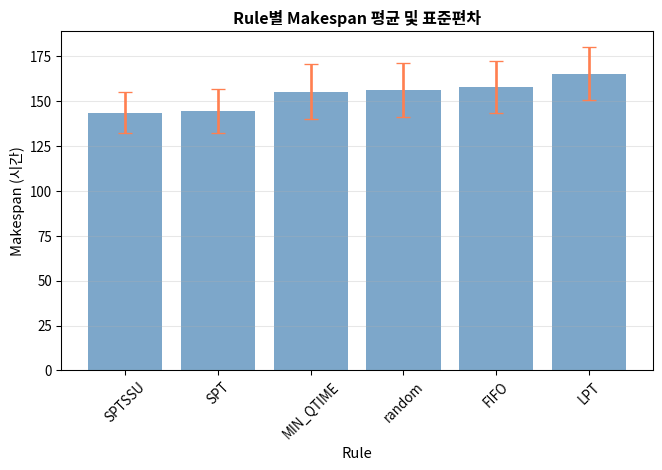

In [7]:
fig, ax = plt.subplots()

# Rule별 Makespan 평균 및 표준편차
makespan_stats = metrics_df.groupby('rule')['makespan'].agg(['mean', 'std']).sort_values('mean')

# Barplot with error bars
x_pos = range(len(makespan_stats))
ax.bar(x_pos, makespan_stats['mean'], yerr=makespan_stats['std'],
       capsize=5, alpha=0.7, color='steelblue', error_kw={'linewidth': 2, 'ecolor': 'coral'})

ax.set_xlabel('Rule', fontsize=11)
ax.set_ylabel('Makespan (시간)', fontsize=11)
ax.set_title('Rule별 Makespan 평균 및 표준편차', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(makespan_stats.index, rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 시각화: Qtime Violation 분석

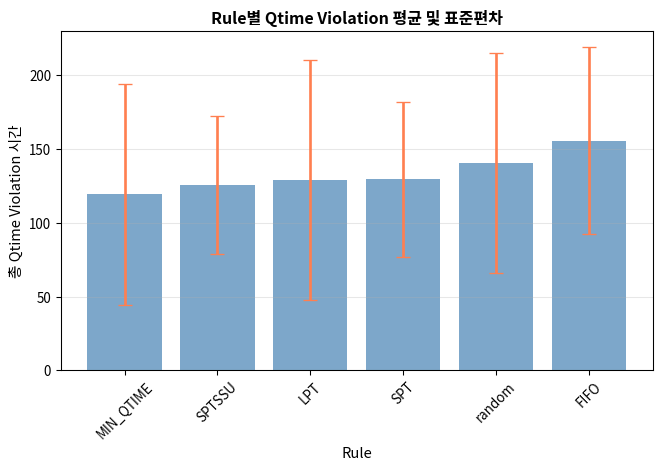

In [8]:
fig, ax = plt.subplots()

# Rule별 Qtime Violation 평균 및 표준편차
qtime_stats = metrics_df.groupby('rule')['qtime_violations'].agg(['mean', 'std']).sort_values('mean')

# Barplot with error bars
x_pos = range(len(qtime_stats))
ax.bar(x_pos, qtime_stats['mean'], yerr=qtime_stats['std'],
       capsize=5, alpha=0.7, color='steelblue', error_kw={'linewidth': 2, 'ecolor': 'coral'})

ax.set_xlabel('Rule', fontsize=11)
ax.set_ylabel('총 Qtime Violation 시간', fontsize=11)
ax.set_title('Rule별 Qtime Violation 평균 및 표준편차', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(qtime_stats.index, rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 시각화: Utilization (설비 가동률) 분석

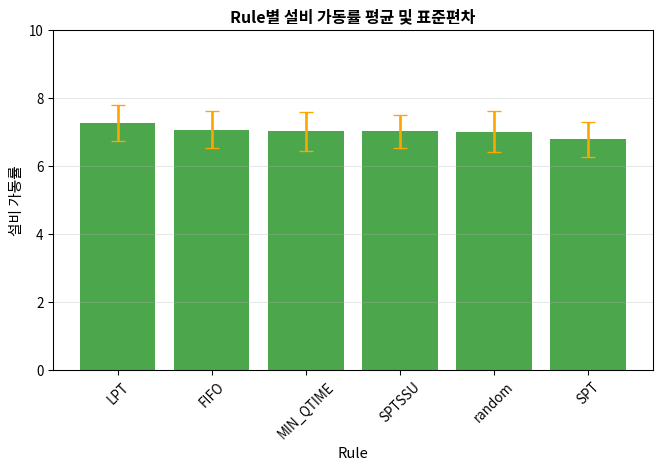

In [9]:
fig, ax = plt.subplots()

# Rule별 Utilization 평균 및 표준편차
util_stats = metrics_df.groupby('rule')['utilization'].agg(['mean', 'std']).sort_values('mean', ascending=False)

# Barplot with error bars
x_pos = range(len(util_stats))
ax.bar(x_pos, util_stats['mean'], yerr=util_stats['std'],
       capsize=5, alpha=0.7, color='green', error_kw={'linewidth': 2, 'ecolor': 'orange'})

ax.set_xlabel('Rule', fontsize=11)
ax.set_ylabel('설비 가동률', fontsize=11)
ax.set_title('Rule별 설비 가동률 평균 및 표준편차', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(util_stats.index, rotation=45)
ax.set_ylim([0, 10])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 시각화: Avg Job Time 분석

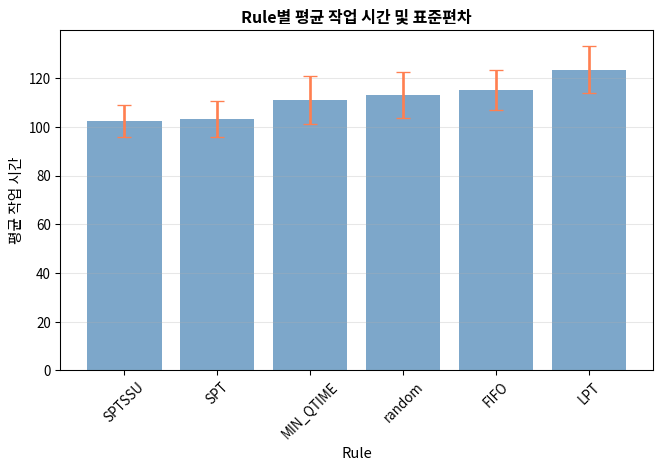

In [10]:
fig, ax = plt.subplots()

# Rule별 Avg Job Time 평균 및 표준편차
job_time_stats = metrics_df.groupby('rule')['avg_job_time'].agg(['mean', 'std']).sort_values('mean')

# Barplot with error bars
x_pos = range(len(job_time_stats))
ax.bar(x_pos, job_time_stats['mean'], yerr=job_time_stats['std'],
       capsize=5, alpha=0.7, color='steelblue', error_kw={'linewidth': 2, 'ecolor': 'coral'})

ax.set_xlabel('Rule', fontsize=11)
ax.set_ylabel('평균 작업 시간', fontsize=11)
ax.set_title('Rule별 평균 작업 시간 및 표준편차', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(job_time_stats.index, rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 시각화: PM & Repair 분석

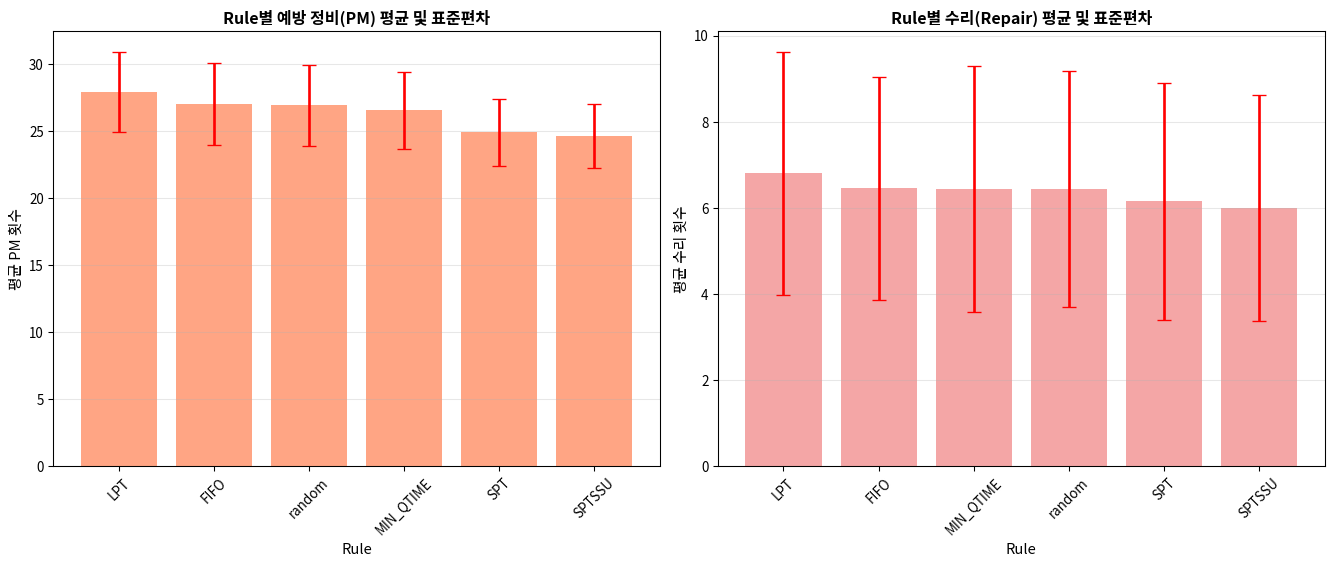

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PM 비교
pm_stats = metrics_df.groupby('rule')['n_pm'].agg(['mean', 'std']).sort_values('mean', ascending=False)
x_pos = range(len(pm_stats))
axes[0].bar(x_pos, pm_stats['mean'], yerr=pm_stats['std'],
            capsize=5, alpha=0.7, color='coral', error_kw={'linewidth': 2, 'ecolor': 'red'})
axes[0].set_xlabel('Rule', fontsize=11)
axes[0].set_ylabel('평균 PM 횟수', fontsize=11)
axes[0].set_title('Rule별 예방 정비(PM) 평균 및 표준편차', fontsize=12, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(pm_stats.index, rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Repair 비교
repair_stats = metrics_df.groupby('rule')['n_repairs'].agg(['mean', 'std']).sort_values('mean', ascending=False)
x_pos = range(len(repair_stats))
axes[1].bar(x_pos, repair_stats['mean'], yerr=repair_stats['std'],
            capsize=5, alpha=0.7, color='lightcoral', error_kw={'linewidth': 2, 'ecolor': 'red'})
axes[1].set_xlabel('Rule', fontsize=11)
axes[1].set_ylabel('평균 수리 횟수', fontsize=11)
axes[1].set_title('Rule별 수리(Repair) 평균 및 표준편차', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(repair_stats.index, rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 시각화: 시간 구성 분석 (Stacked Bar Chart)

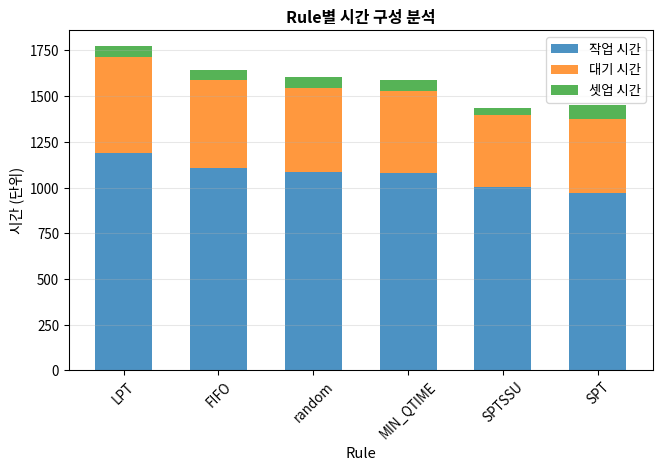

In [12]:
fig, ax = plt.subplots()

# Rule별 시간 구성 평균
time_components = metrics_df.groupby('rule')[['total_working_time', 'total_waiting_time', 'total_setup_time']].mean()
time_components = time_components.sort_values('total_working_time', ascending=False)

# Stacked barplot
x_pos = range(len(time_components))
width = 0.6
ax.bar(x_pos, time_components['total_working_time'], width, label='작업 시간', alpha=0.8)
ax.bar(x_pos, time_components['total_waiting_time'], width,
       bottom=time_components['total_working_time'], label='대기 시간', alpha=0.8)
ax.bar(x_pos, time_components['total_setup_time'], width,
       bottom=time_components['total_working_time'] + time_components['total_waiting_time'],
       label='셋업 시간', alpha=0.8)

ax.set_xlabel('Rule', fontsize=11)
ax.set_ylabel('시간 (단위)', fontsize=11)
ax.set_title('Rule별 시간 구성 분석', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(time_components.index, rotation=45)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 성능 순위 분석

In [13]:
# 각 지표별로 좋은 순서대로 랭킹
ranking = pd.DataFrame()

for rule in metrics_df['rule'].unique():
    rule_data = metrics_df[metrics_df['rule'] == rule]

    ranking = pd.concat([ranking, pd.DataFrame({
        'Rule': [rule],
        'Avg Makespan': [rule_data['makespan'].mean()],
        'Avg Qtime Viol': [rule_data['qtime_violations'].mean()],
        'Avg Utilization': [rule_data['utilization'].mean()],
        'Avg Job Time': [rule_data['avg_job_time'].mean()],
        'Total PM': [rule_data['n_pm'].sum()],
        'Total Repairs': [rule_data['n_repairs'].sum()]
    })], ignore_index=True)

ranking = ranking.set_index('Rule')

print("=== 성능 순위 분석 ===")
print("\n1. Makespan:")
print(ranking['Avg Makespan'].sort_values().round(2))

print("\n2. Qtime Violation:")
print(ranking['Avg Qtime Viol'].sort_values().round(2))

print("\n3. 설비 가동률:")
print(ranking['Avg Utilization'].sort_values(ascending=False).round(3))

print("\n4. 평균 작업 시간:")
print(ranking['Avg Job Time'].sort_values().round(2))

print("\n5. 총 PM 횟수:")
print(ranking['Total PM'].sort_values().astype(int))

print("\n6. 총 Repair 횟수:")
print(ranking['Total Repairs'].sort_values().astype(int))

=== 성능 순위 분석 ===

1. Makespan:
Rule
SPTSSU       143.40
SPT          144.11
MIN_QTIME    155.00
random       155.96
FIFO         157.47
LPT          164.91
Name: Avg Makespan, dtype: float64

2. Qtime Violation:
Rule
MIN_QTIME    119.28
SPTSSU       125.79
LPT          129.15
SPT          129.44
random       140.48
FIFO         155.68
Name: Avg Qtime Viol, dtype: float64

3. 설비 가동률:
Rule
LPT          7.269
FIFO         7.072
MIN_QTIME    7.026
SPTSSU       7.025
random       7.018
SPT          6.788
Name: Avg Utilization, dtype: float64

4. 평균 작업 시간:
Rule
SPTSSU       102.44
SPT          103.26
MIN_QTIME    111.13
random       113.10
FIFO         114.98
LPT          123.42
Name: Avg Job Time, dtype: float64

5. 총 PM 횟수:
Rule
SPTSSU       24615
SPT          24929
MIN_QTIME    26557
random       26927
FIFO         27056
LPT          27952
Name: Total PM, dtype: int64

6. 총 Repair 횟수:
Rule
SPTSSU       6000
SPT          6150
random       6435
MIN_QTIME    6442
FIFO         6455
LPT       